# Support Vector Machine (SVM): A Complete Guide

Welcome to this comprehensive tutorial on Support Vector Machines!

## What Problem Does SVM Solve?

Imagine you're a security guard at a party, standing exactly in the middle between two groups of people. Your job is to stand in the position that gives both groups the maximum possible personal space. That's essentially what an SVM does!

**Support Vector Machine** finds the optimal decision boundary (hyperplane) to separate different classes with the **maximum margin**.

### What You'll Learn:
1. The Intuition: How SVM thinks about boundaries
2. The Mathematics: Step-by-step derivation (beginner + advanced)  
3. The Kernel Trick: How SVM handles complex, non-linear patterns
4. Practical Skills: Implementing SVM with different settings


---
## Chapter 1: The Iris Dataset

The **Iris dataset** was introduced by **Sir Ronald Fisher in 1936**. It contains measurements from three species of Iris flowers:

| Species | Description |
|:--------|:------------|
| **Setosa** | Smallest flowers, wide petals |
| **Versicolor** | Medium-sized |
| **Virginica** | Largest species |

**Features (4):** Sepal Length, Sepal Width, Petal Length, Petal Width (all in cm)

**Statistics:** 150 samples (50 per species), no missing values, balanced classes.


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

plt.style.use('seaborn-v0_8-whitegrid')

iris = load_iris()
print("Features:", iris.feature_names)
print("Classes:", iris.target_names)
print("Shape:", iris.data.shape)


Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']
Shape: (150, 4)


### Visualizing the Iris Dataset

Let's plot different feature combinations to see how the species are distributed.


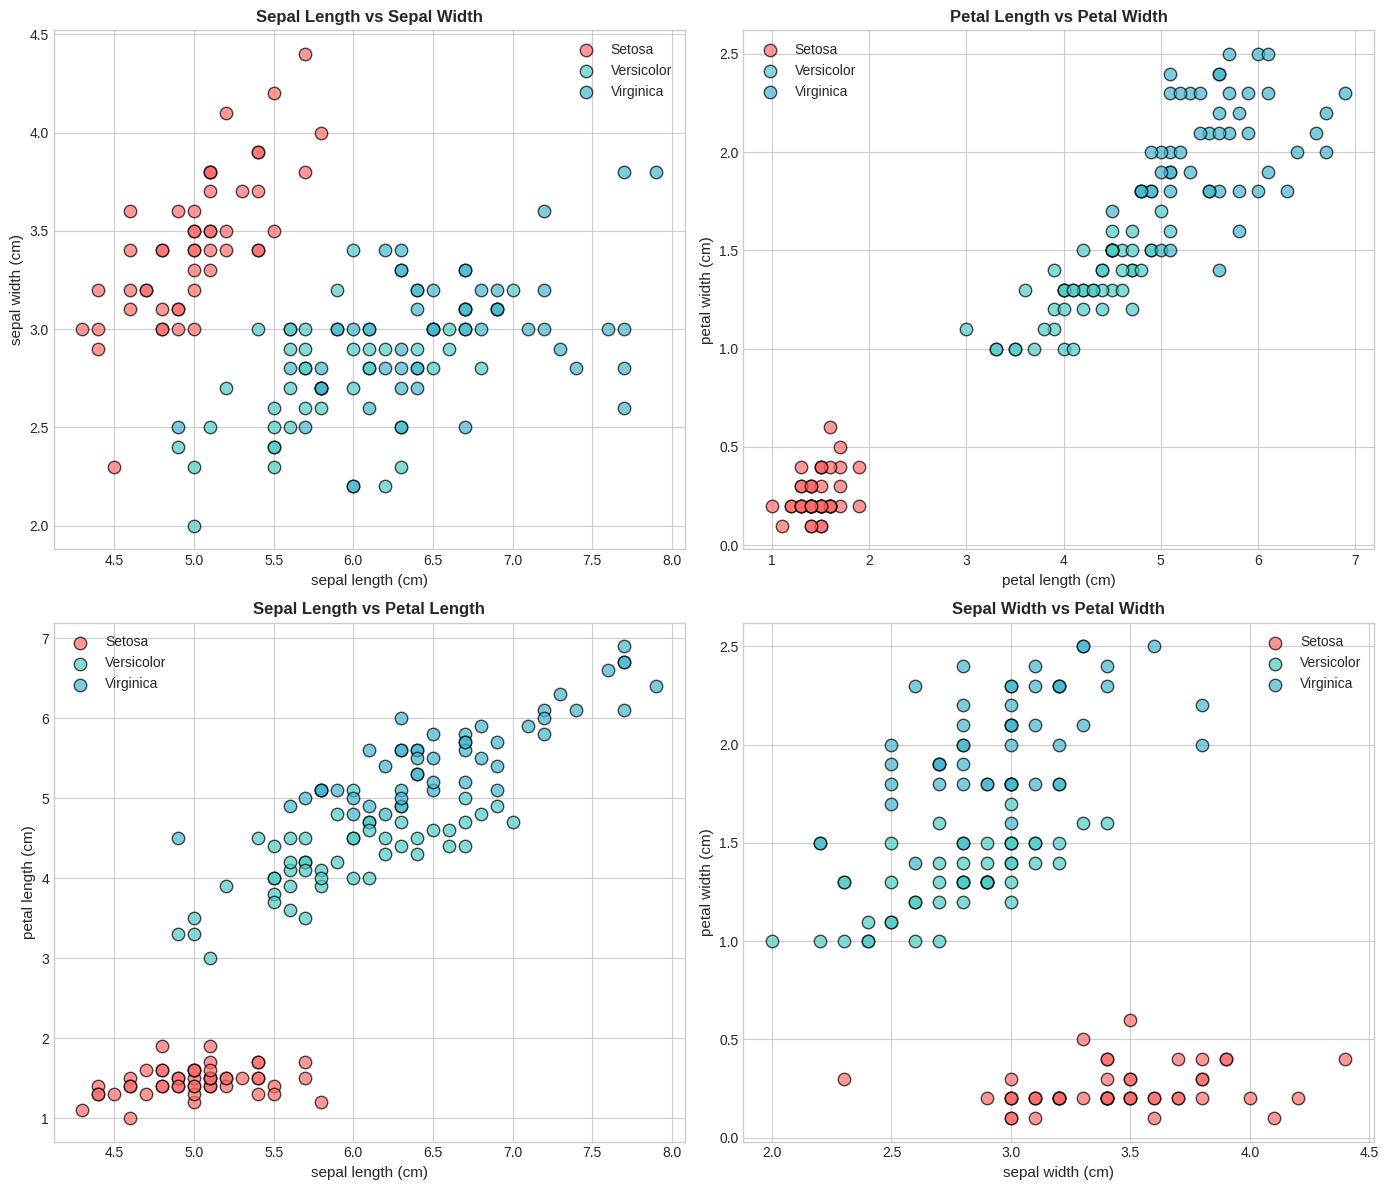

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

feature_pairs = [
    (0, 1, 'Sepal Length vs Sepal Width'),
    (2, 3, 'Petal Length vs Petal Width'),
    (0, 2, 'Sepal Length vs Petal Length'),
    (1, 3, 'Sepal Width vs Petal Width'),
]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, (f1, f2, title) in enumerate(feature_pairs):
    ax = axes[idx // 2, idx % 2]
    for species_idx, species in enumerate(iris.target_names):
        mask = iris.target == species_idx
        ax.scatter(iris.data[mask, f1], iris.data[mask, f2],
                   c=colors[species_idx], label=species.capitalize(), s=80, alpha=0.7, edgecolors='black')
    ax.set_xlabel(iris.feature_names[f1], fontsize=11)
    ax.set_ylabel(iris.feature_names[f2], fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()


### Key Observation

Notice how **Setosa** (red) is easily separable from the other two species. However, **Versicolor** and **Virginica** overlap significantly.


---
## Chapter 2: Classification Problem

**Classification** = assigning data points to categories.

For Iris: Given flower's measurements, predict which species.


---
## Chapter 3: Why Maximum Margin?

Consider two groups of points. Many lines can separate them, but only ONE maximizes the distance to both groups.

**Why it matters:**
1. **Generalization**: Boundary far from both classes is robust to new data
2. **Confidence**: Points near boundary could be misclassified easily
3. **Overfitting Prevention**: Too-close boundaries may memorize noise


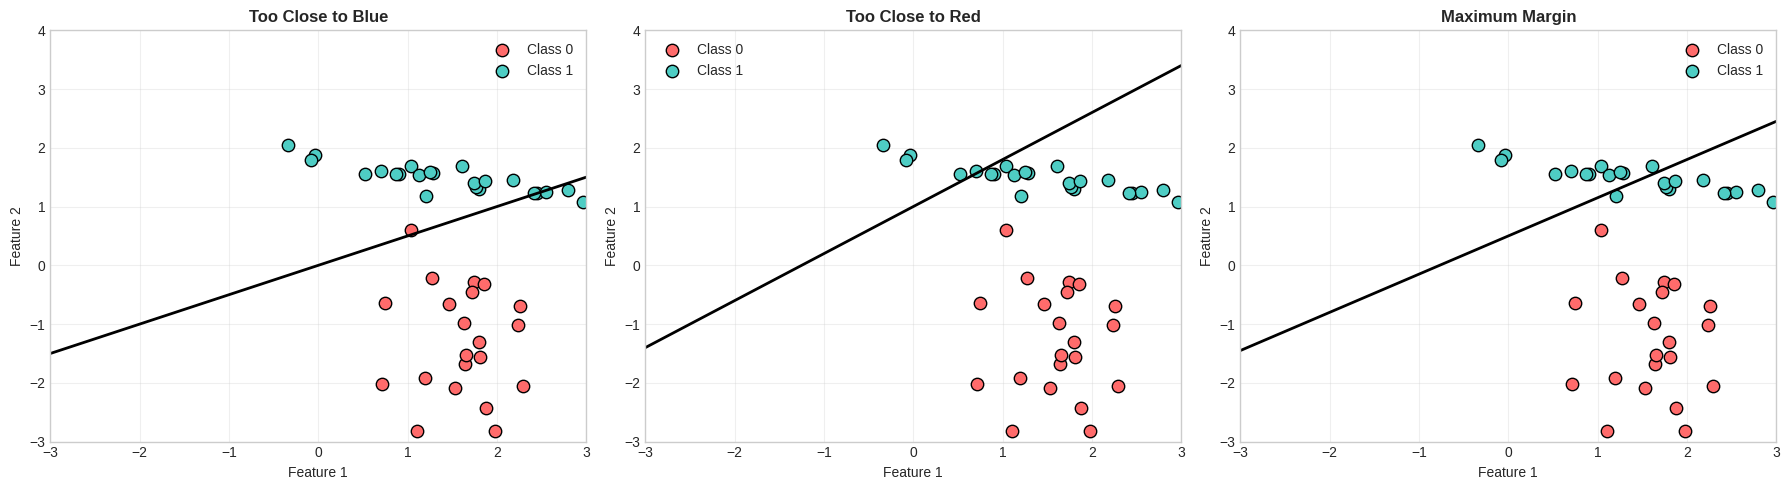

In [21]:
from sklearn.datasets import make_classification

X_demo, y_demo = make_classification(n_samples=50, n_features=2, n_redundant=0, 
                                     n_informative=2, n_clusters_per_class=1, 
                                     class_sep=1.5, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
boundaries = [
    {'slope': 0.5, 'intercept': 0, 'label': 'Too Close to Blue'},
    {'slope': 0.8, 'intercept': 1, 'label': 'Too Close to Red'},
    {'slope': 0.65, 'intercept': 0.5, 'label': 'Maximum Margin'},
]

for idx, boundary in enumerate(boundaries):
    ax = axes[idx]
    ax.scatter(X_demo[y_demo==0, 0], X_demo[y_demo==0, 1], c='#FF6B6B', s=80, label='Class 0', edgecolors='k')
    ax.scatter(X_demo[y_demo==1, 0], X_demo[y_demo==1, 1], c='#4ECDC4', s=80, label='Class 1', edgecolors='k')
    x_line = np.linspace(-3, 3, 100)
    ax.plot(x_line, boundary['slope'] * x_line + boundary['intercept'], 'k-', linewidth=2)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 4)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.set_title(boundary['label'], fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Chapter 4: Maximum Margin Intuition

**Security Guard Metaphor:**
- Keep maximum distance from both groups
- Stand in the center of available space
- Only closest people (support vectors) determine position

### Key SVM Terms

| Term | Explanation |
|:-----|:------------|
| **Hyperplane** | The decision boundary |
| **Margin** | Distance to nearest points |
| **Support Vectors** | Critical points that define the margin |


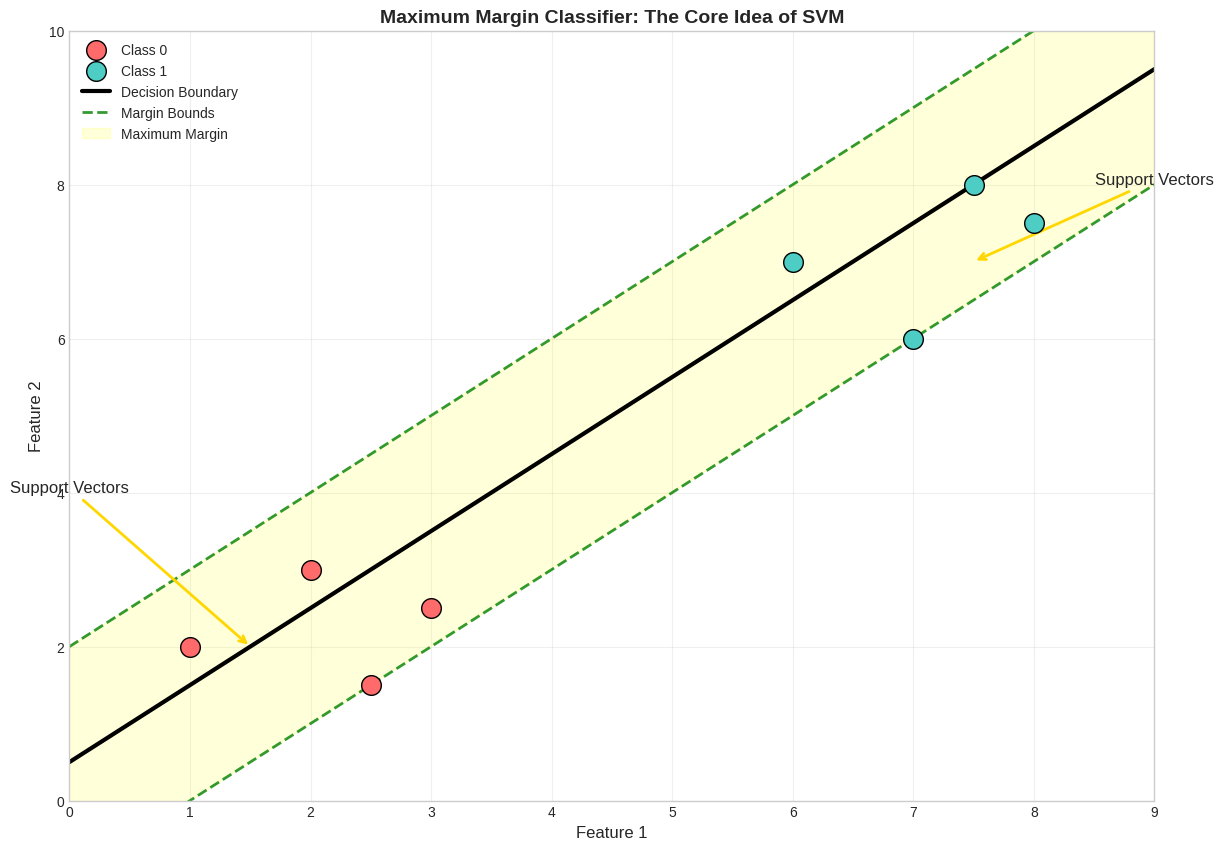

In [22]:
fig, ax = plt.subplots(figsize=(14, 10))

X_simple = np.array([[1, 2], [2, 3], [3, 2.5], [2.5, 1.5], [6, 7], [7, 6], [8, 7.5], [7.5, 8]])
y_simple = np.array([0, 0, 0, 0, 1, 1, 1, 1])

ax.scatter(X_simple[y_simple==0, 0], X_simple[y_simple==0, 1], c='#FF6B6B', s=200, label='Class 0', edgecolors='k', zorder=5)
ax.scatter(X_simple[y_simple==1, 0], X_simple[y_simple==1, 1], c='#4ECDC4', s=200, label='Class 1', edgecolors='k', zorder=5)

ax.annotate('Support Vectors', xy=(1.5, 2), xytext=(0, 4), fontsize=12, ha='center',
            arrowprops=dict(arrowstyle='->', color='gold', lw=2))
ax.annotate('Support Vectors', xy=(7.5, 7), xytext=(9, 8), fontsize=12, ha='center',
            arrowprops=dict(arrowstyle='->', color='gold', lw=2))

x_line = np.linspace(0, 9, 100)
y_line = x_line + 0.5
ax.plot(x_line, y_line, 'k-', linewidth=3, label='Decision Boundary')
ax.plot(x_line, y_line - 1.5, 'g--', linewidth=2, alpha=0.8)
ax.plot(x_line, y_line + 1.5, 'g--', linewidth=2, alpha=0.8, label='Margin Bounds')
ax.fill_between(x_line, y_line - 1.5, y_line + 1.5, alpha=0.15, color='yellow', label='Maximum Margin')

ax.set_xlim(0, 9); ax.set_ylim(0, 10)
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('Maximum Margin Classifier: The Core Idea of SVM', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.show()


### Why Only Support Vectors Matter?

Only the points touching the margin bounds matter. Moving other points doesn't change the boundary. This is called **sparsity**.


---
## Chapter 5: Linear SVM Mathematics (Beginner)

### SVM's Hyperplane Equation

$$w \cdot x + b = 0$$

Where:
- $w$ = weight vector (perpendicular to boundary)
- $x$ = a point on the boundary
- $b$ = bias (shifts the boundary)
- $w \cdot x$ = dot product = $w_1 x_1 + w_2 x_2$

### Margin Width

$$	ext{Margin} = rac{2}{\|w\|}$$

To maximize margin, minimize $\|w\|$.

### Classification Rule

$$f(x) = w \cdot x + b$$

- If $f(x) > 0$: Predict Class +1
- If $f(x) < 0$: Predict Class -1


---
## Chapter 6: Linear SVM Mathematics (Advanced)

### The Optimization Problem

$$\min_{w, b} rac{1}{2} \|w\|^2 \quad 	ext{s.t.} \quad y_i(w \cdot x_i + b) \geq 1$$

### The Dual Problem

$$\max_alpha \sum alpha_i - rac{1}{2} \sum alpha_i alpha_j y_i y_j (x_i \cdot x_j)$$

subject to $\sum alpha_i y_i = 0, alpha_i \geq 0$

### The Kernel Trick Revealed

$$f(x) = \sum alpha_i^* y_i (x_i \cdot x) + b^*$$

The solution is a sum of **dot products** - these can be replaced by **kernels**!

### KKT Conditions

| $alpha_i$ | Condition | Interpretation |
|:-----------|:----------|:---------------|
| $alpha_i = 0$ | $> 1$ | Outside margin (irrelevant) |
| $0 < alpha_i < C$ | $= 1$ | On margin (support vector) |
| $alpha_i = C$ | $< 1$ | Inside margin |


---
## Chapter 7: The Kernel Trick


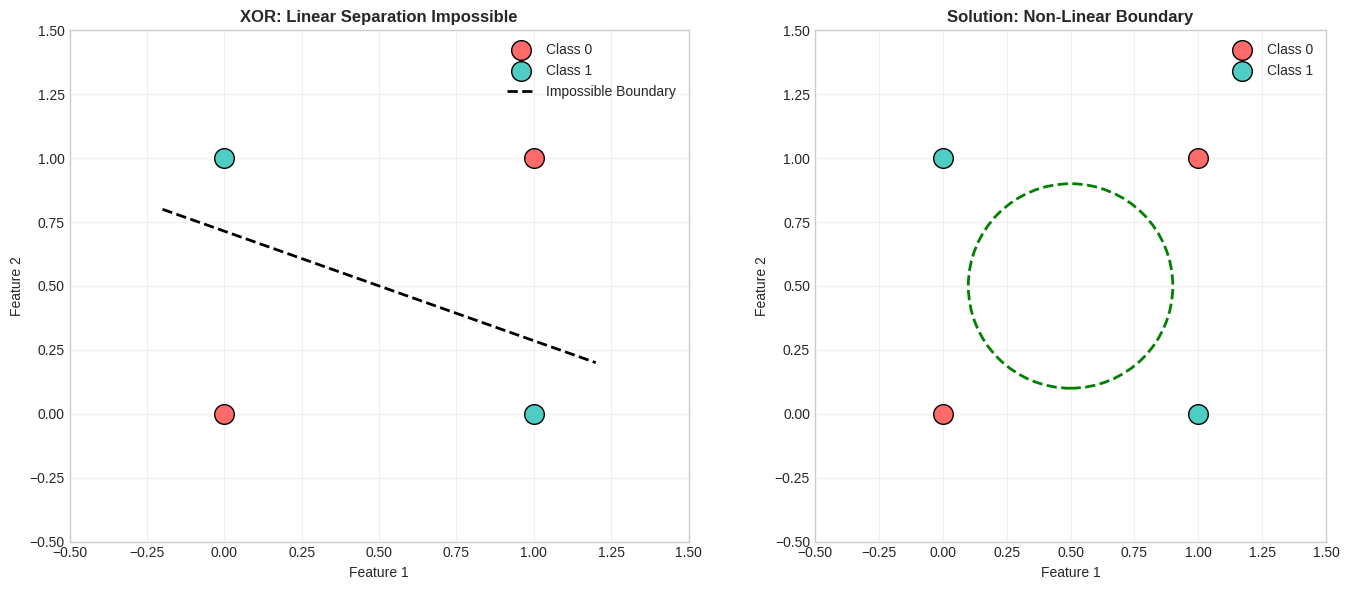

In [23]:
X_xor = np.array([[0, 0], [1, 1], [0, 1], [1, 0]])
y_xor = np.array([0, 0, 1, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(X_xor[y_xor==0, 0], X_xor[y_xor==0, 1], c='#FF6B6B', s=200, label='Class 0', edgecolors='k')
ax.scatter(X_xor[y_xor==1, 0], X_xor[y_xor==1, 1], c='#4ECDC4', s=200, label='Class 1', edgecolors='k')
ax.plot([-0.2, 1.2], [0.8, 0.2], 'k--', linewidth=2, label='Impossible Boundary')
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.set_title('XOR: Linear Separation Impossible', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(X_xor[y_xor==0, 0], X_xor[y_xor==0, 1], c='#FF6B6B', s=200, label='Class 0', edgecolors='k')
ax.scatter(X_xor[y_xor==1, 0], X_xor[y_xor==1, 1], c='#4ECDC4', s=200, label='Class 1', edgecolors='k')
circle1 = plt.Circle((0.5, 0.5), 0.4, fill=False, color='green', linewidth=2, linestyle='--')
ax.add_patch(circle1)
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.set_title('Solution: Non-Linear Boundary', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_aspect('equal')

plt.tight_layout()
plt.show()


### The Kernel Trick: Lift to Higher Dimensions

**Key insight**: In higher dimensions, XOR becomes linearly separable!

Mapping: $\phi(x_1, x_2) = (x_1, x_2, x_1 x_2)$

Now a plane can separate them!

### Kernel Function

Instead of computing $\phi(x)$ explicitly, use the **kernel function**:

$$K(x, x') = \phi(x) \cdot \phi(x')$$

**The Magic**: We never compute $\phi(x)$ - just compute $K(x, x')$ efficiently!


---
## Chapter 8: Kernel Types Explained

| Kernel | Formula | Best For |
|:-------|:--------|:---------|
| **Linear** | $K(x, x') = x \cdot x'$ | High-dimensional, linearly separable |
| **RBF (Gaussian)** | $K(x, x') = \exp(-\gamma \|x-x'\|^2)$ | Most non-linear cases |
| **Polynomial** | $K(x, x') = (x \cdot x' + c)^d$ | Polynomial patterns |
| **Sigmoid** | $K(x, x') = 	anh(alpha x \cdot x' + c)$ | Neural network-like |


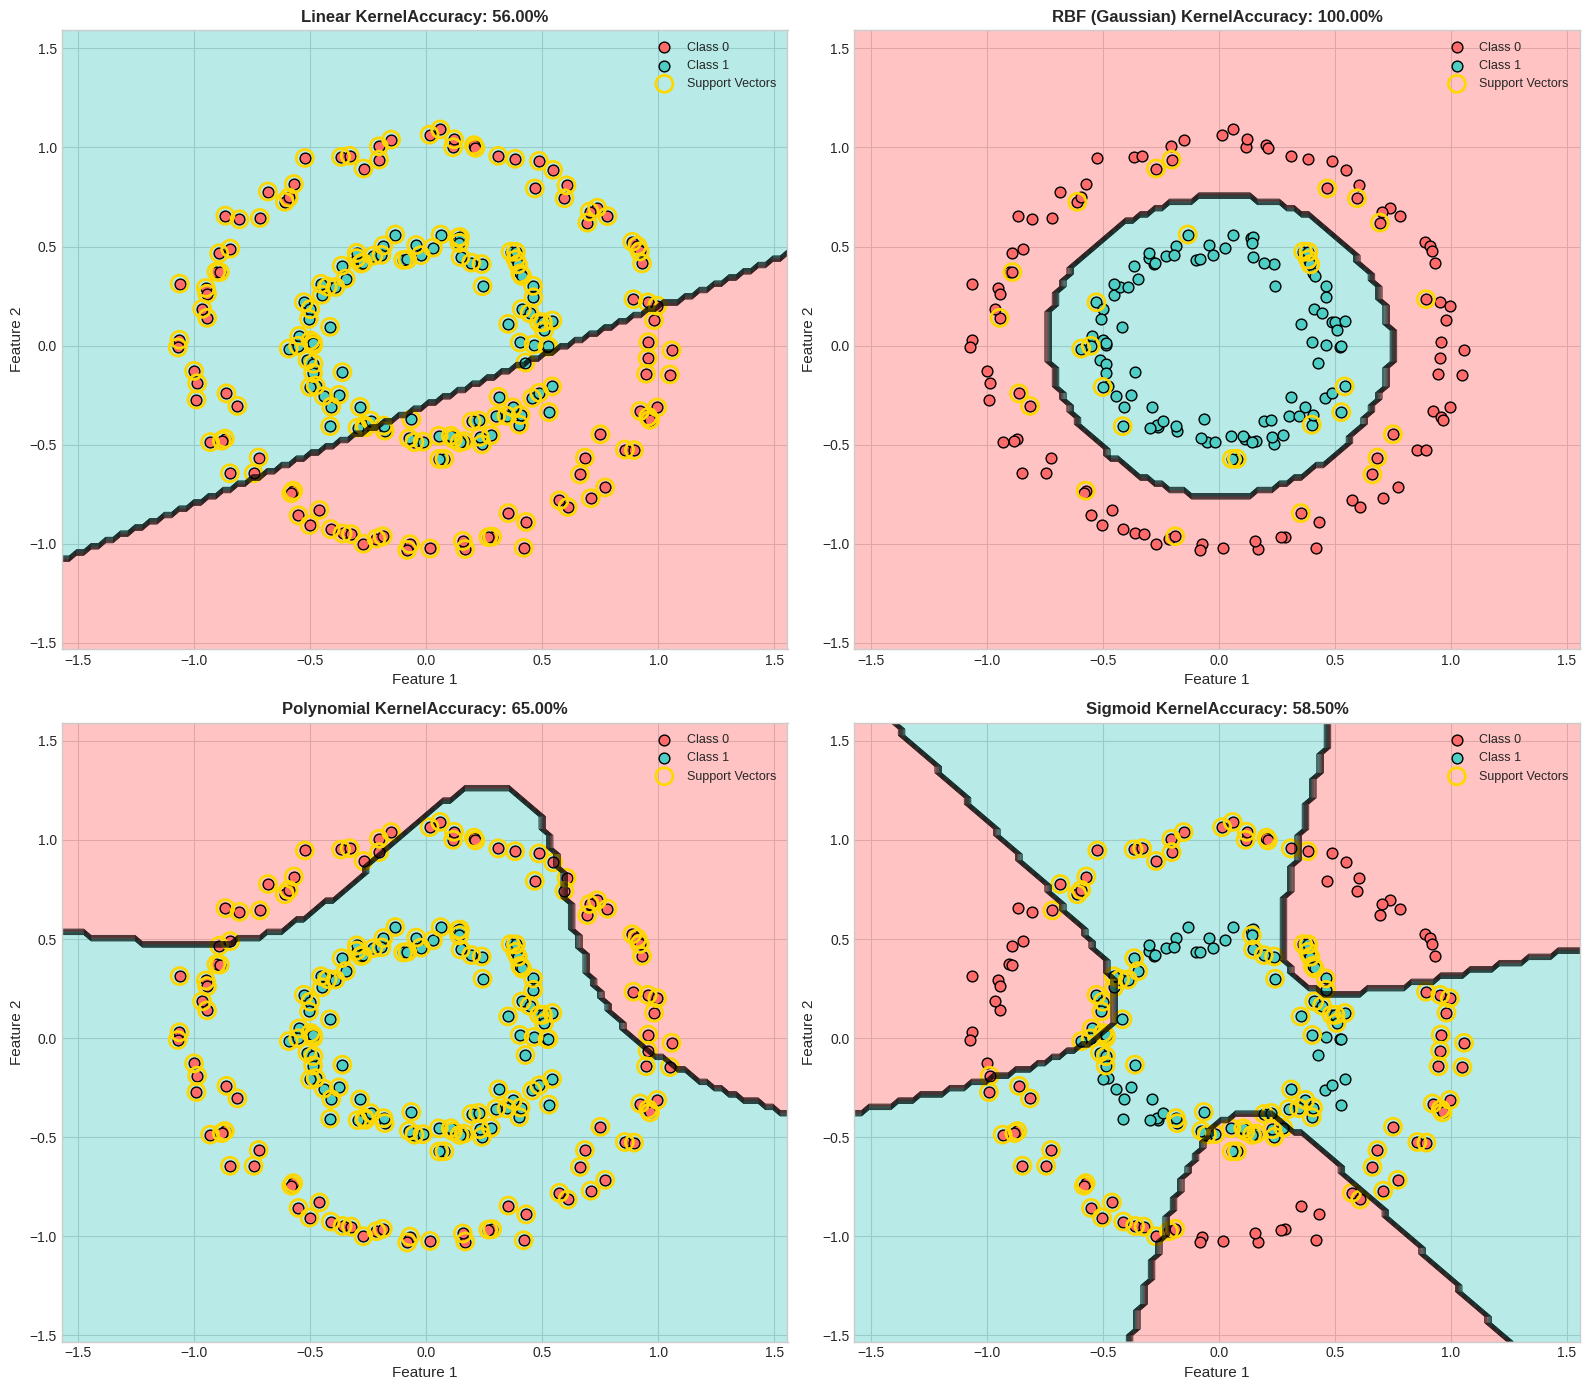

In [24]:
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC
from sklearn.datasets import make_circles

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

X_circles, y_circles = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)

kernels = ['linear', 'rbf', 'poly', 'sigmoid']
titles = ['Linear', 'RBF (Gaussian)', 'Polynomial', 'Sigmoid']

x_min, x_max = X_circles[:, 0].min() - 0.5, X_circles[:, 0].max() + 0.5
y_min, y_max = X_circles[:, 1].min() - 0.5, X_circles[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

for idx, (kernel, title) in enumerate(zip(kernels, titles)):
    ax = axes[idx // 2, idx % 2]
    svm = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42)
    svm.fit(X_circles, y_circles)
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=ListedColormap(['#FF6B6B', '#4ECDC4']))
    ax.contour(xx, yy, Z, colors='k', linewidths=0.5)
    ax.scatter(X_circles[y_circles==0, 0], X_circles[y_circles==0, 1], c='#FF6B6B', s=60, label='Class 0', edgecolors='k')
    ax.scatter(X_circles[y_circles==1, 0], X_circles[y_circles==1, 1], c='#4ECDC4', s=60, label='Class 1', edgecolors='k')
    ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1], s=150, facecolors='none', edgecolors='gold', linewidths=2, label='Support Vectors')
    accuracy = svm.score(X_circles, y_circles)
    ax.set_xlabel('Feature 1', fontsize=11)
    ax.set_ylabel('Feature 2', fontsize=11)
    ax.set_title(f'{title} KernelAccuracy: {accuracy:.2%}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


### When to Use Each Kernel?

1. **Linear**: High-dimensional data (text, genes) - often works best linearly
2. **RBF**: Default choice - works well for most non-linear problems
3. **Polynomial**: When decision boundary has known polynomial degree
4. **Sigmoid**: Neural network contexts (not always stable)


---
## Chapter 9: Synthetic Datasets


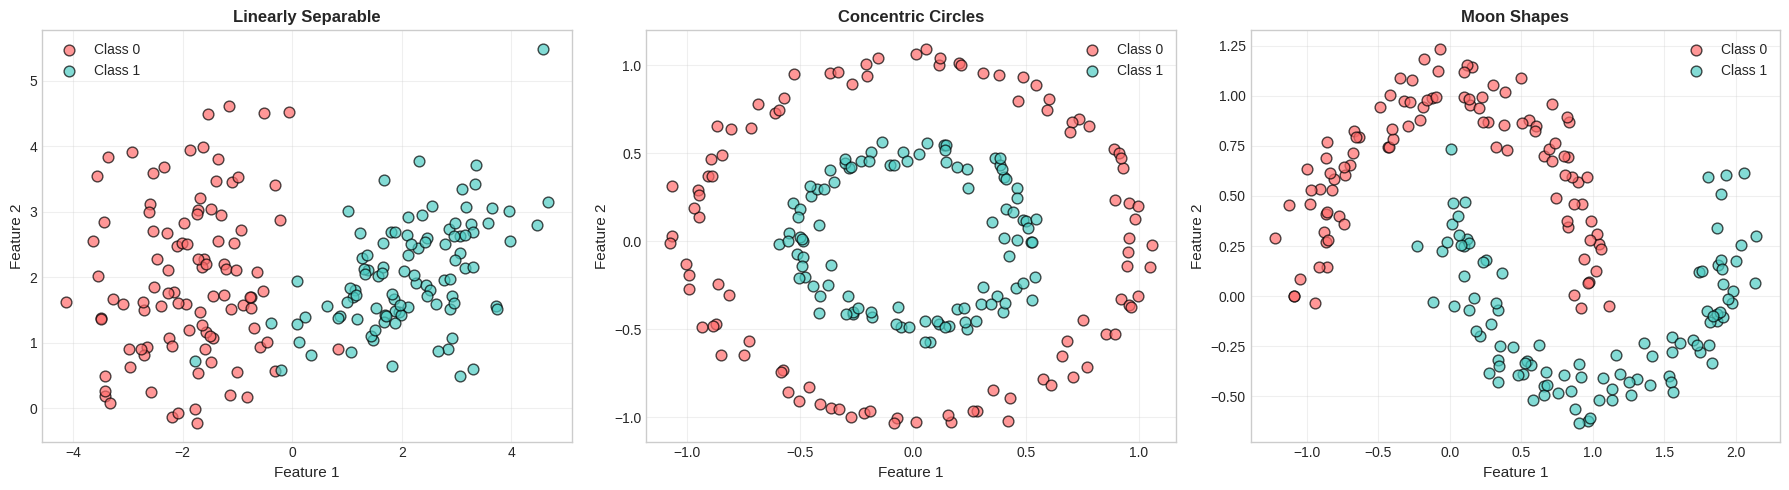

In [25]:
from sklearn.datasets import make_circles, make_moons, make_classification

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

X_linear, y_linear = make_classification(n_samples=200, n_features=2, n_redundant=0, n_informative=2,
                                         n_clusters_per_class=1, class_sep=2.0, random_state=42)
X_circles, y_circles = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)

datasets = [(X_linear, y_linear, 'Linearly Separable'), (X_circles, y_circles, 'Concentric Circles'), (X_moons, y_moons, 'Moon Shapes')]
colors = ['#FF6B6B', '#4ECDC4']

for idx, (X, y, title) in enumerate(datasets):
    ax = axes[idx]
    for class_idx in [0, 1]:
        mask = y == class_idx
        ax.scatter(X[mask, 0], X[mask, 1], c=colors[class_idx], s=60, label=f'Class {class_idx}', edgecolors='k', alpha=0.7)
    ax.set_xlabel('Feature 1', fontsize=11)
    ax.set_ylabel('Feature 2', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


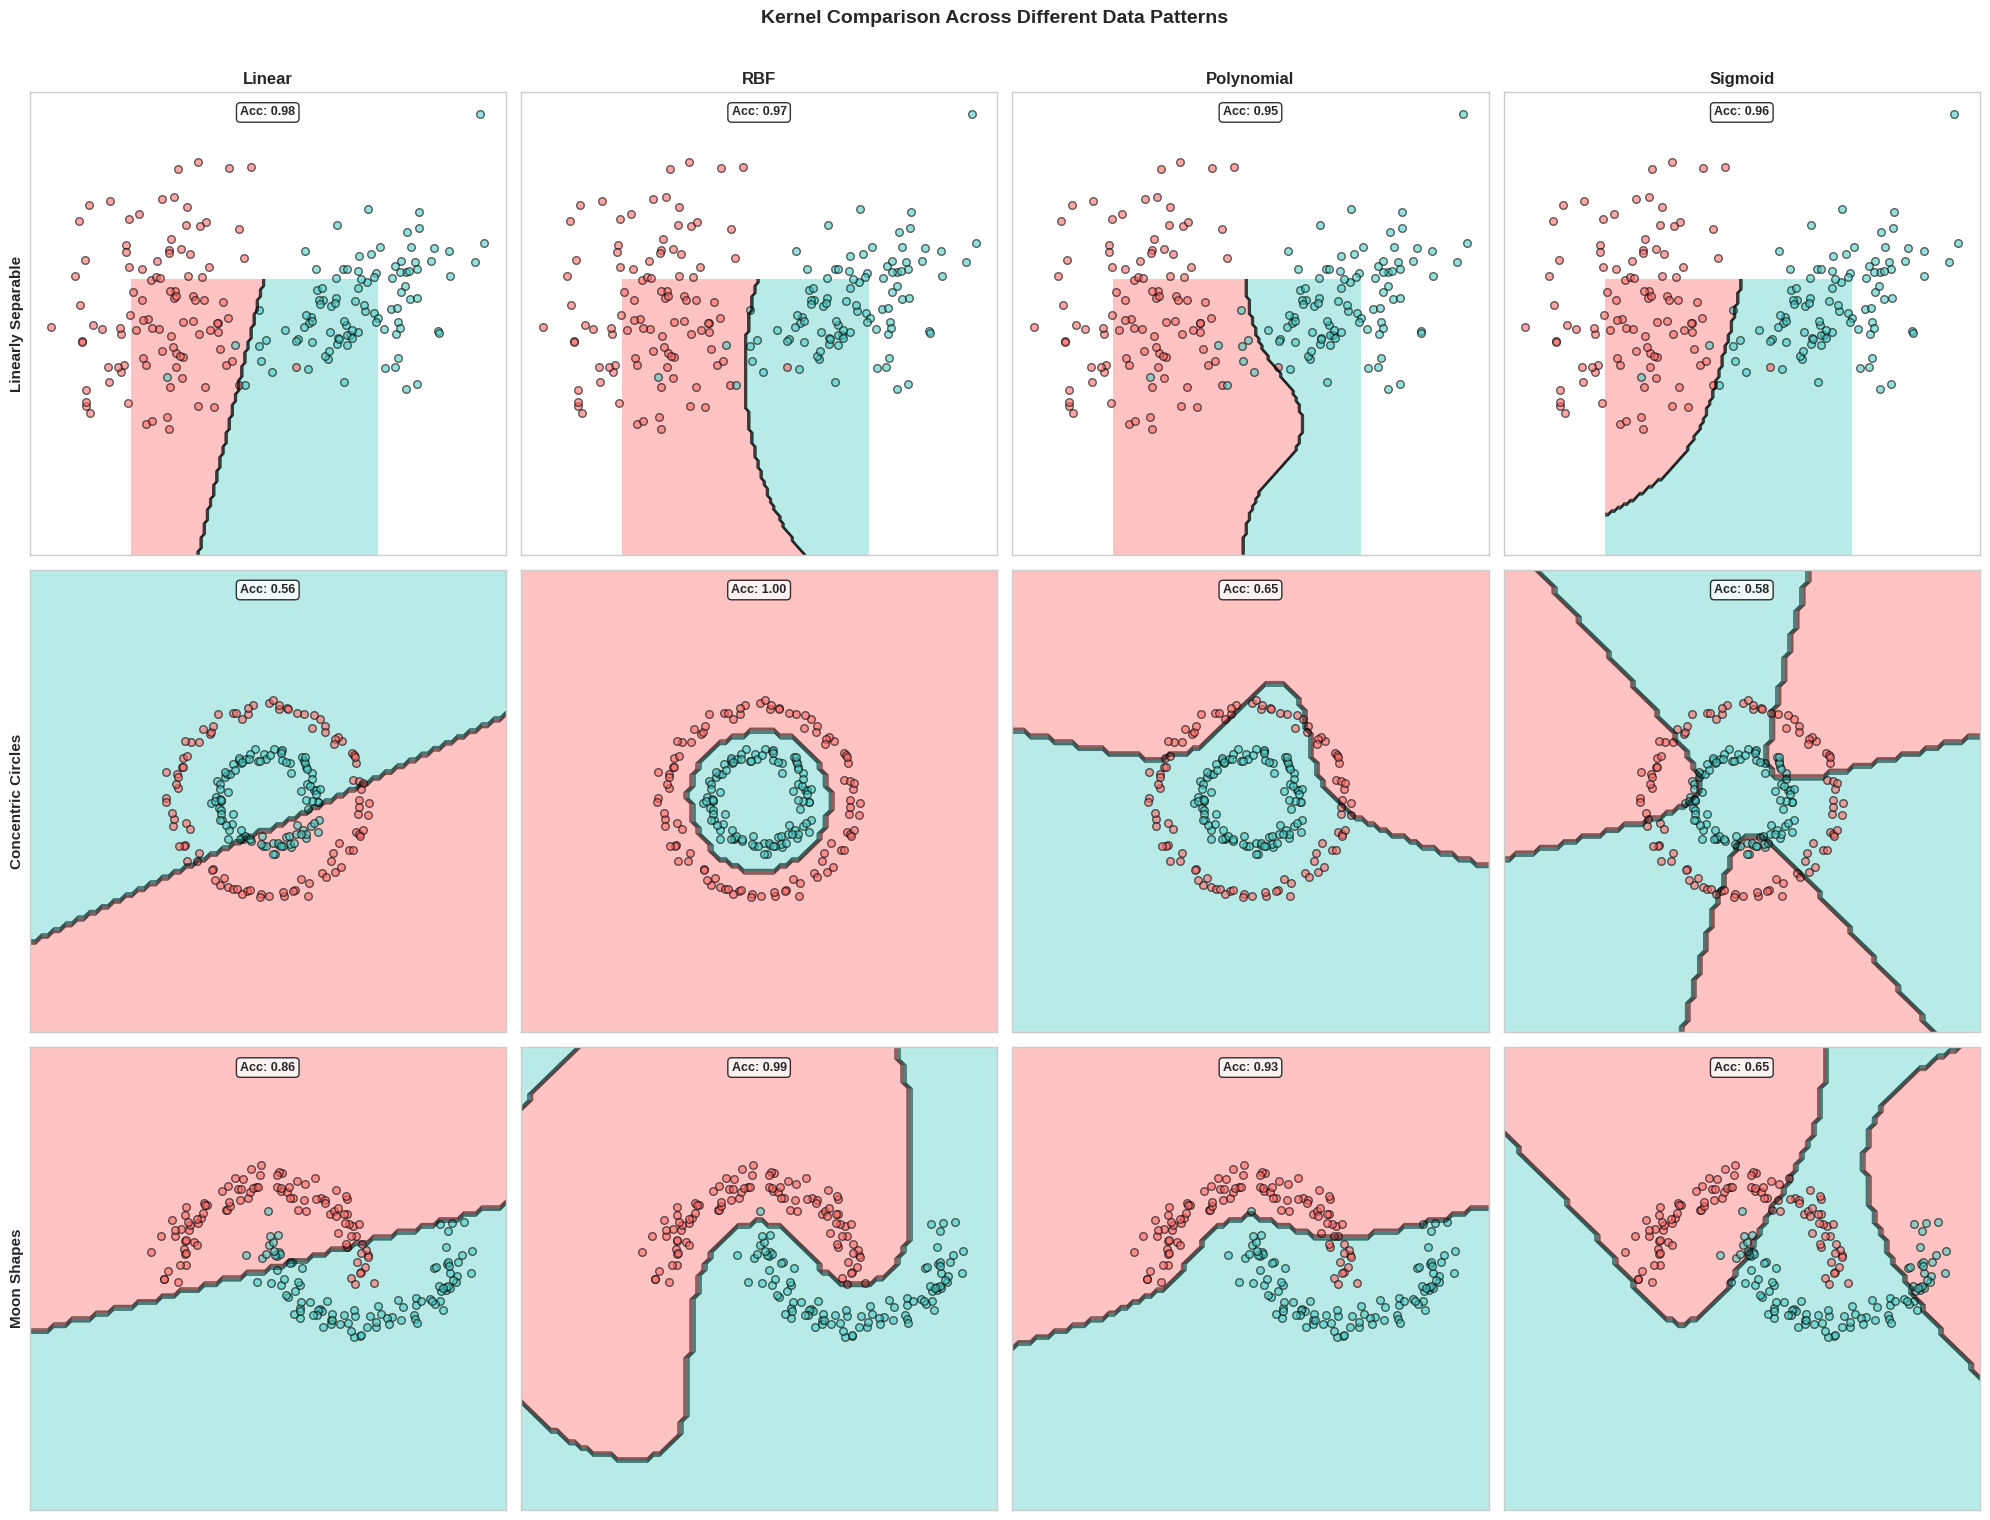

In [26]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

kernels = ['linear', 'rbf', 'poly', 'sigmoid']
kernel_titles = ['Linear', 'RBF', 'Polynomial', 'Sigmoid']

x_min, x_max = -2.5, 2.5
y_min, y_max = -2.5, 2.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 80), np.linspace(y_min, y_max, 80))

for row_idx, (X, y, dataset_name) in enumerate(datasets):
    for col_idx, (kernel, kernel_title) in enumerate(zip(kernels, kernel_titles)):
        ax = axes[row_idx, col_idx]
        svm = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42)
        svm.fit(X, y)
        Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.4, cmap=ListedColormap(['#FF6B6B', '#4ECDC4']))
        ax.contour(xx, yy, Z, colors='k', linewidths=0.3)
        ax.scatter(X[y==0, 0], X[y==0, 1], c='#FF6B6B', s=30, edgecolors='k', alpha=0.6)
        ax.scatter(X[y==1, 0], X[y==1, 1], c='#4ECDC4', s=30, edgecolors='k', alpha=0.6)
        accuracy = svm.score(X, y)
        if col_idx == 0: ax.set_ylabel(dataset_name, fontsize=11, fontweight='bold')
        if row_idx == 0: ax.set_title(kernel_title, fontsize=12, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
        ax.text(0.5, 0.95, f'Acc: {accuracy:.2f}', transform=ax.transAxes, ha='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Kernel Comparison Across Different Data Patterns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Key Observations

| Dataset | Linear | RBF | Poly | Sigmoid |
|:--------|:------:|:---:|:----:|:-------:|
| Linearly Separable | Excellent | Good | Good | Good |
| Concentric Circles | Poor | Excellent | Poor | Poor |
| Moon Shapes | Poor | Excellent | Good | Good |

**RBF is most versatile, Linear is best when data is truly linearly separable.**


---
## Chapter 10: Hyperparameters C and gamma

### C: Regularization Parameter

- **Small C**: Wide margin, allows points inside (underfitting)
- **Large C**: Narrow margin, hard boundary (overfitting)

### gamma: Influence Radius (RBF only)

$$	ext{RBF} = \exp(-\gamma \|x-x'\|^2)$$

- **Small gamma**: Smooth boundary, far influence
- **Large gamma**: Complex boundary, local only


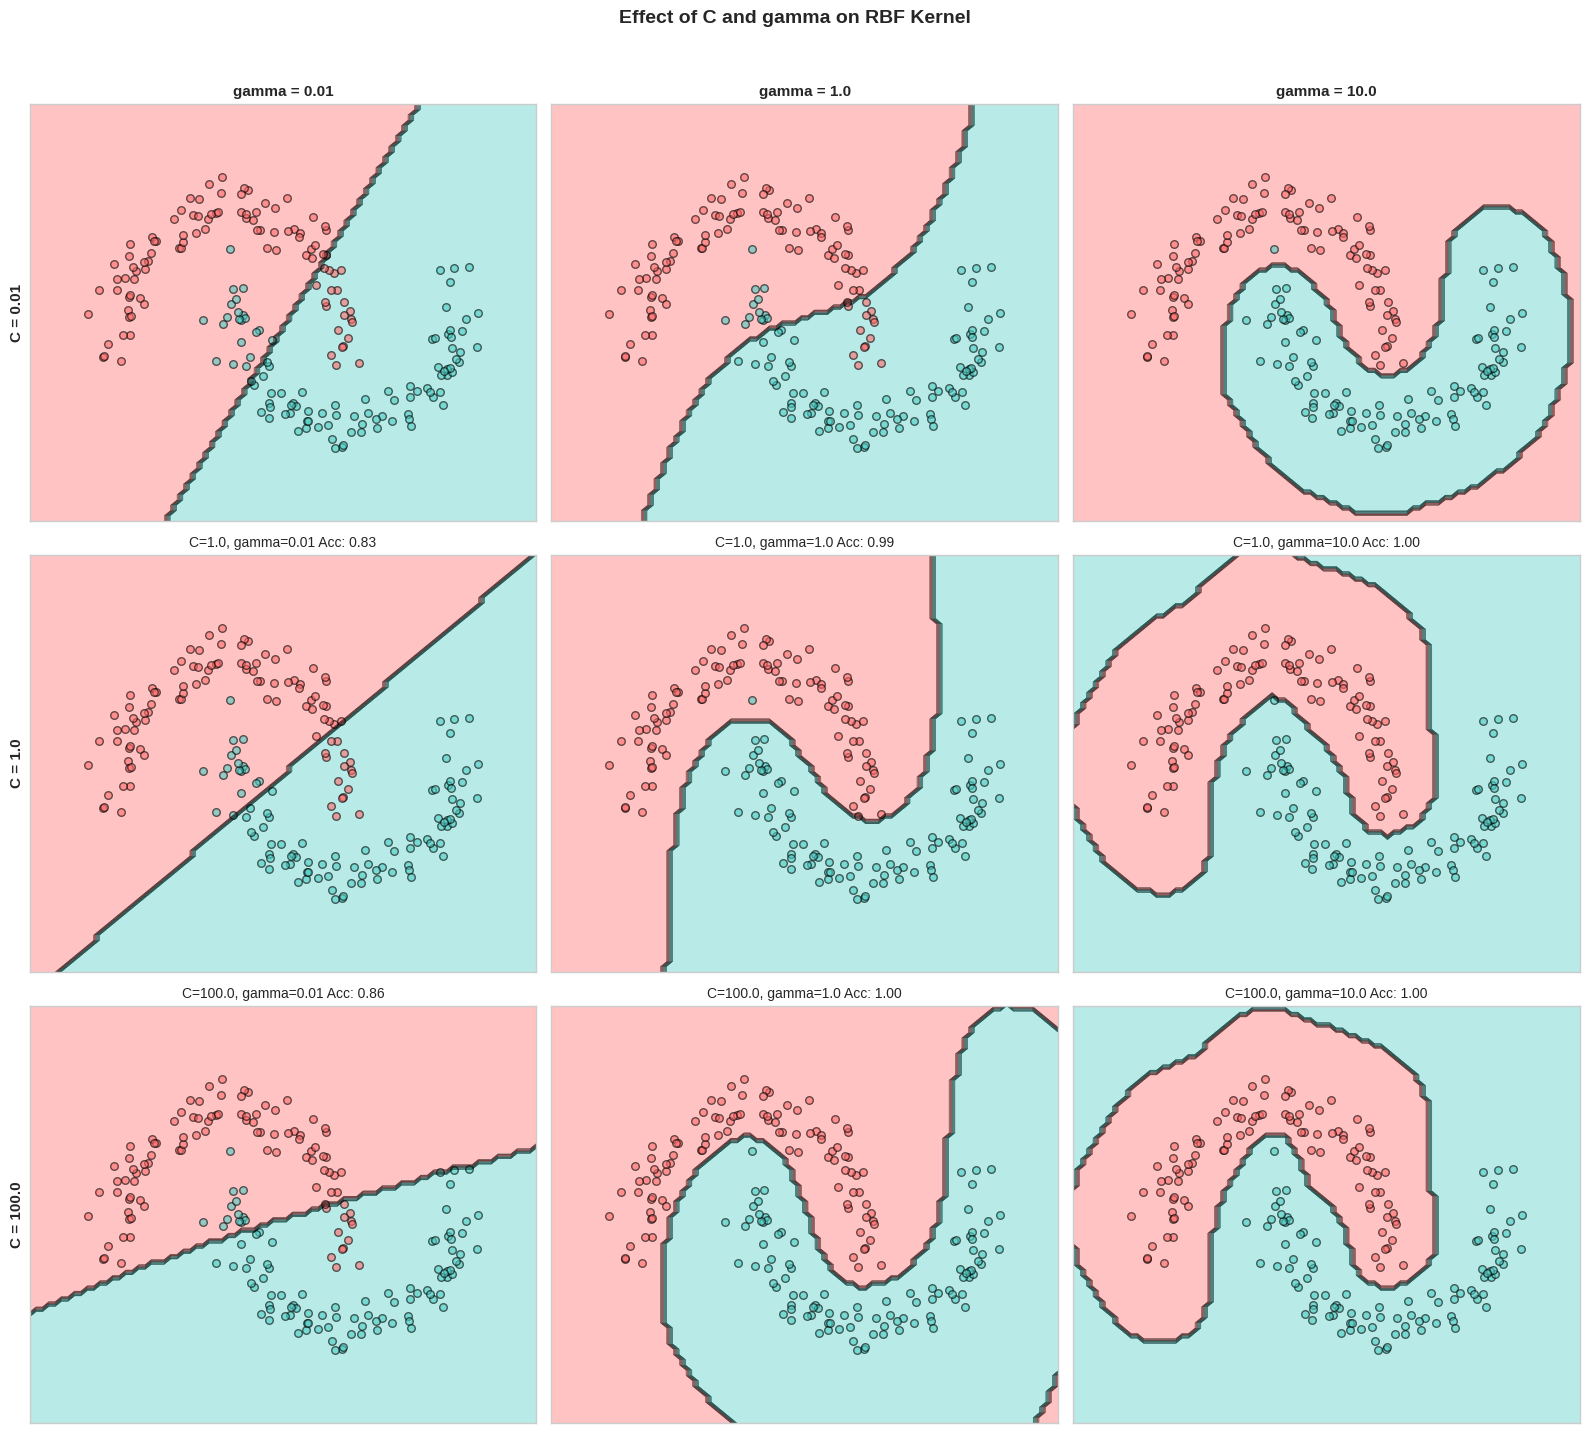

In [28]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

C_values = [0.01, 1.0, 100.0]
gamma_values = [0.01, 1.0, 10.0]

x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 80), np.linspace(y_min, y_max, 80))

for i, C in enumerate(C_values):
    for j, gamma in enumerate(gamma_values):
        ax = axes[i, j]
        svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
        svm.fit(X_moons, y_moons)
        Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.4, cmap=ListedColormap(['#FF6B6B', '#4ECDC4']))
        ax.contour(xx, yy, Z, colors='k', linewidths=0.3)
        ax.scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1], c='#FF6B6B', s=30, edgecolors='k', alpha=0.6)
        ax.scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1], c='#4ECDC4', s=30, edgecolors='k', alpha=0.6)
        accuracy = svm.score(X_moons, y_moons)
        ax.set_title(f'C={C}, gamma={gamma} Acc: {accuracy:.2f}', fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

for i, C in enumerate(C_values): axes[i, 0].set_ylabel(f'C = {C}', fontsize=11, fontweight='bold')
for j, gamma in enumerate(gamma_values): axes[0, j].set_title(f'gamma = {gamma}', fontsize=11, fontweight='bold')

plt.suptitle('Effect of C and gamma on RBF Kernel', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Trade-offs Summary

| Parameter | Low Value | High Value | Risk |
|:----------|:----------|:-----------|:-----|
| **C** | Wide margin, simpler | Narrow margin, complex | Low: underfit, High: overfit |
| **gamma** | Smooth, far influence | Complex, local only | Low: underfit, High: overfit |


---
## Chapter 11: Why Scaling Matters

SVM uses **distance calculations** ($K(x, x') = \exp(-\gamma \|x-x'\|^2)$), so **feature scales matter enormously!**

If one feature ranges 0-1000 and another 0-1, distance is dominated by the first feature.


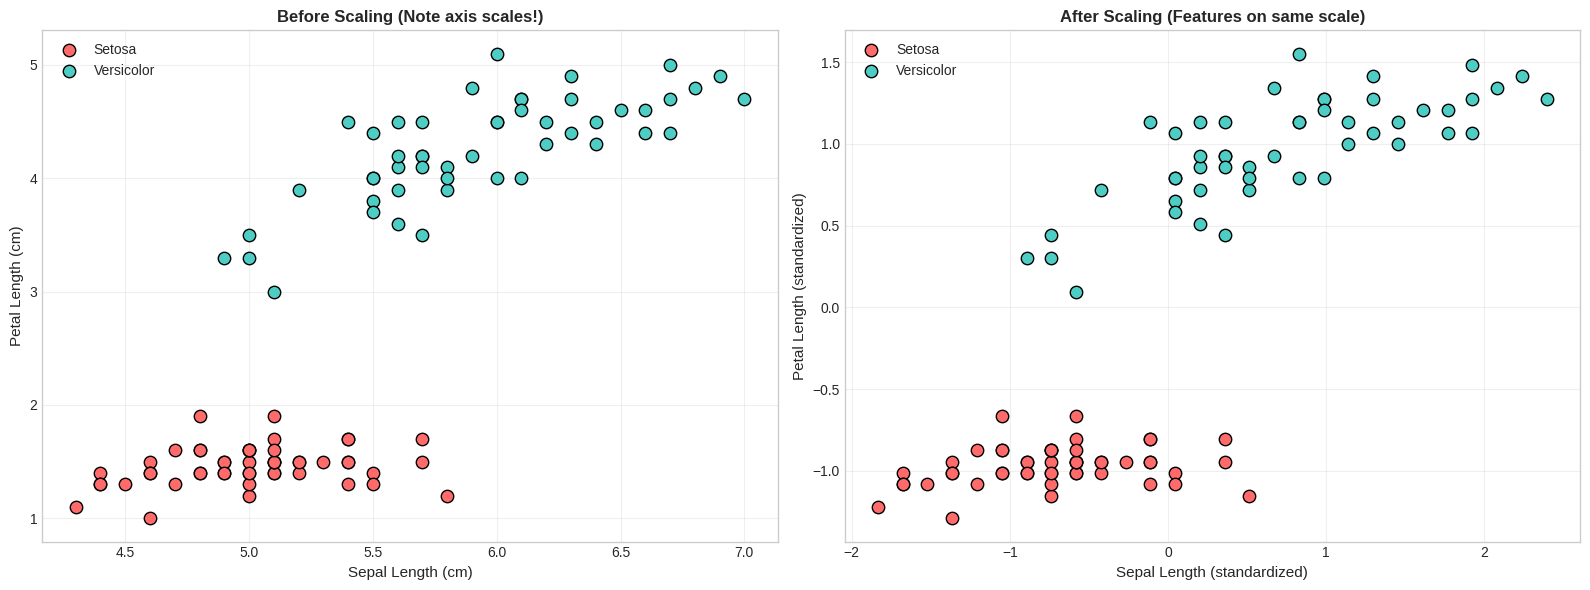

In [31]:
from sklearn.preprocessing import StandardScaler

iris_raw = load_iris()
X_unscaled = iris_raw.data[:, [0, 2]]
y_iris = iris_raw.target
mask = y_iris < 2
X_unscaled = X_unscaled[mask]
y_iris = y_iris[mask]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unscaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.scatter(X_unscaled[y_iris==0, 0], X_unscaled[y_iris==0, 1], c='#FF6B6B', s=80, label='Setosa', edgecolors='k')
ax.scatter(X_unscaled[y_iris==1, 0], X_unscaled[y_iris==1, 1], c='#4ECDC4', s=80, label='Versicolor', edgecolors='k')
ax.set_xlabel('Sepal Length (cm)', fontsize=11)
ax.set_ylabel('Petal Length (cm)', fontsize=11)
ax.set_title('Before Scaling (Note axis scales!)', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(X_scaled[y_iris==0, 0], X_scaled[y_iris==0, 1], c='#FF6B6B', s=80, label='Setosa', edgecolors='k')
ax.scatter(X_scaled[y_iris==1, 0], X_scaled[y_iris==1, 1], c='#4ECDC4', s=80, label='Versicolor', edgecolors='k')
ax.set_xlabel('Sepal Length (standardized)', fontsize=11)
ax.set_ylabel('Petal Length (standardized)', fontsize=11)
ax.set_title('After Scaling (Features on same scale)', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Rule of Thumb

**Always scale features before training SVM!**

This ensures: equal feature contribution, faster optimization, stable results.


---
## Chapter 12: Binary Classification Demo


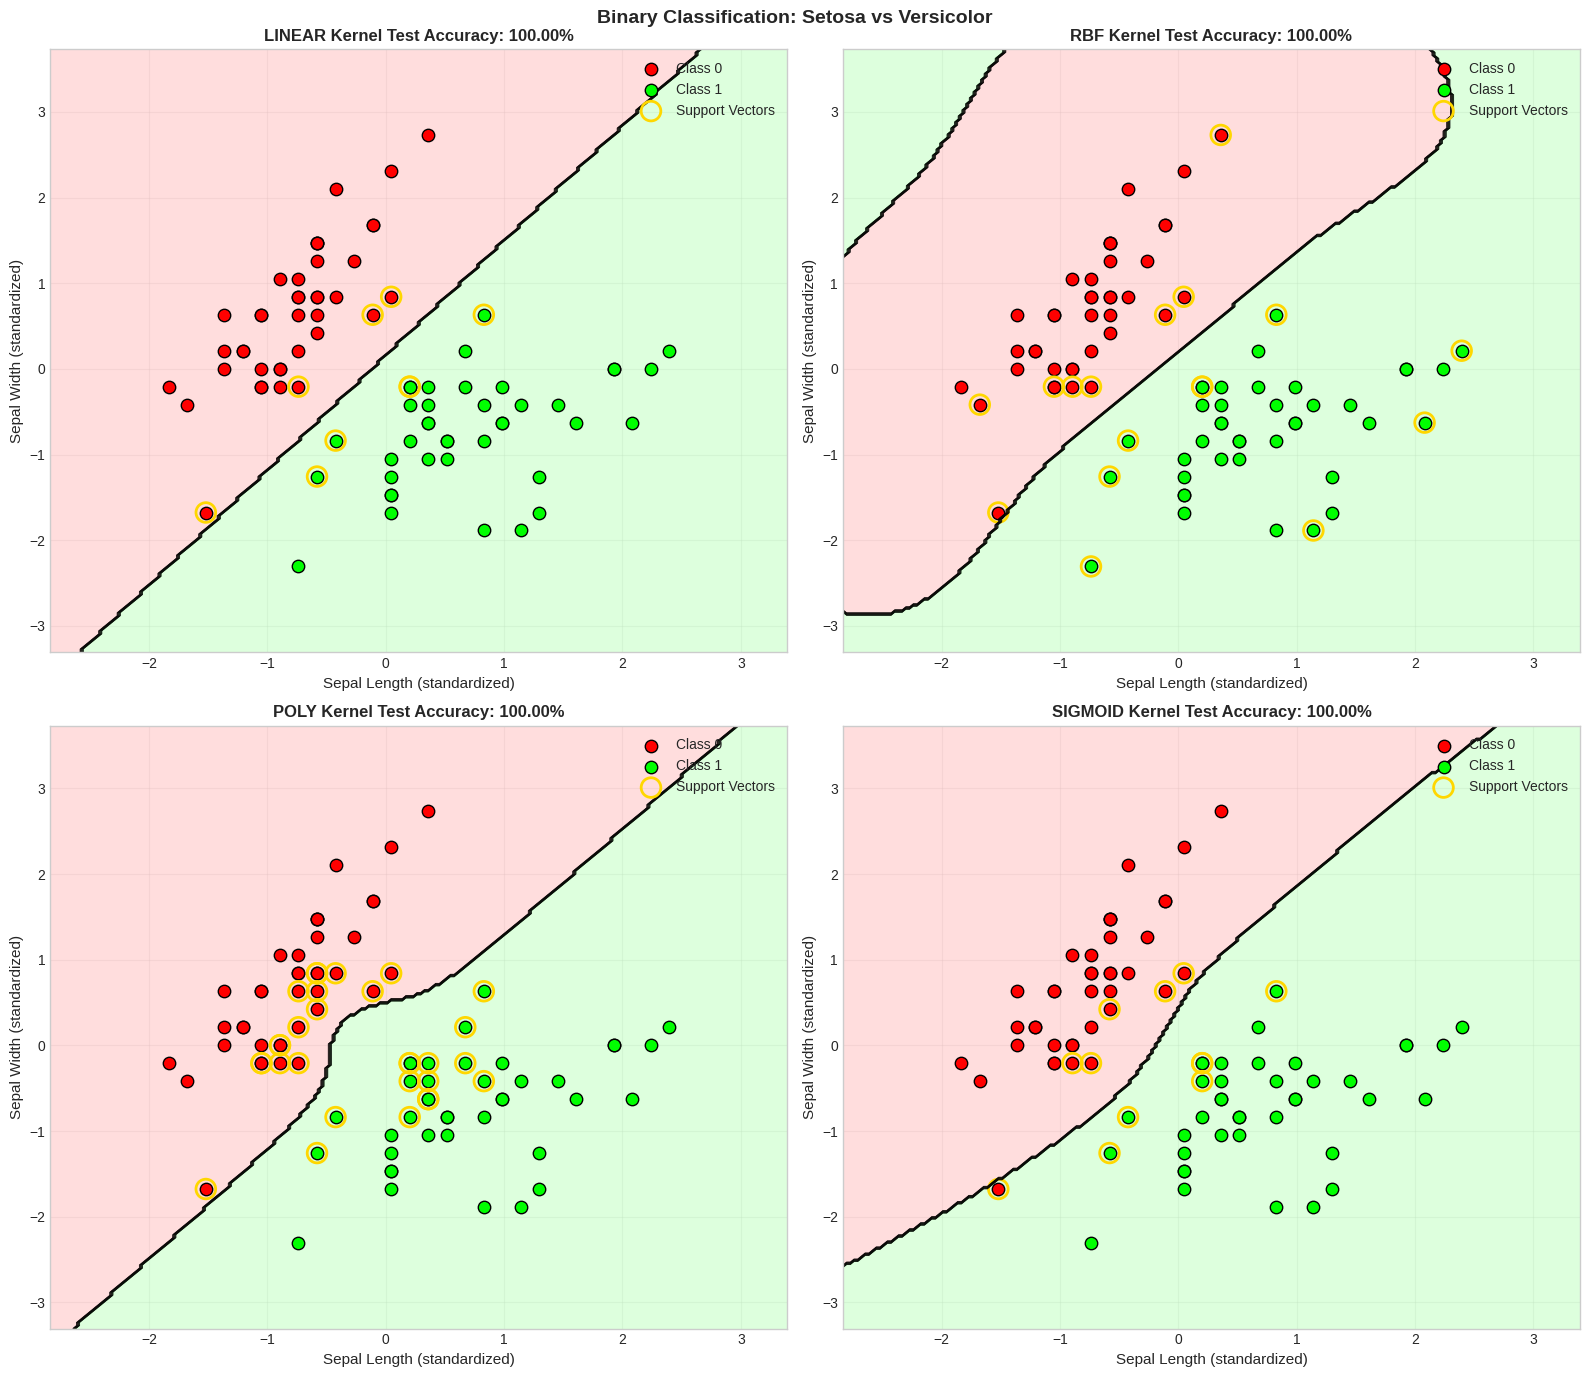

In [33]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load and prepare Iris data
iris = load_iris()
mask = iris.target < 2  # Select Setosa (0) and Versicolor (1)
X, y = iris.data[mask], iris.target[mask]

# Use first two features for 2D visualization
X_2d = X[:, [0, 1]]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_2d)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Train and visualize different kernels
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

for idx, kernel in enumerate(kernels):
    ax = axes[idx // 2, idx % 2]
    svm = SVC(kernel=kernel, C=1.0, random_state=42)
    svm.fit(X_train, y_train)
    
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ['#FF0000', '#00FF00']
    
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)
    ax.contour(xx, yy, Z, colors='k', linewidths=0.5)
    for class_idx in [0, 1]:
        mask_train = y_train == class_idx
        ax.scatter(X_train[mask_train, 0], X_train[mask_train, 1], c=cmap_bold[class_idx], s=80, label=f'Class {class_idx}', edgecolors='k')
    ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1], s=200, facecolors='none', edgecolors='gold', linewidths=2, label='Support Vectors')
    accuracy = svm.score(X_test, y_test)
    ax.set_xlabel('Sepal Length (standardized)', fontsize=11)
    ax.set_ylabel('Sepal Width (standardized)', fontsize=11)
    ax.set_title(f'{kernel.upper()} Kernel Test Accuracy: {accuracy:.2%}', fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Binary Classification: Setosa vs Versicolor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


All kernels achieve high accuracy because Setosa and Versicolor are nearly linearly separable with these features.


---
## Chapter 13: Multi-Class Classification

SVM is binary. For 3-class Iris, sklearn uses **One-vs-Rest (OvR)**:

- Train 3 classifiers: "Setosa vs Rest", "Versicolor vs Rest", "Virginica vs Rest"
- At prediction time, choose the class with highest confidence


In [34]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load full Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Train RBF SVM
svm_multi = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_multi.fit(X_train, y_train)

# Predict
y_pred = svm_multi.predict(X_test)

print("Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=iris.target_names))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


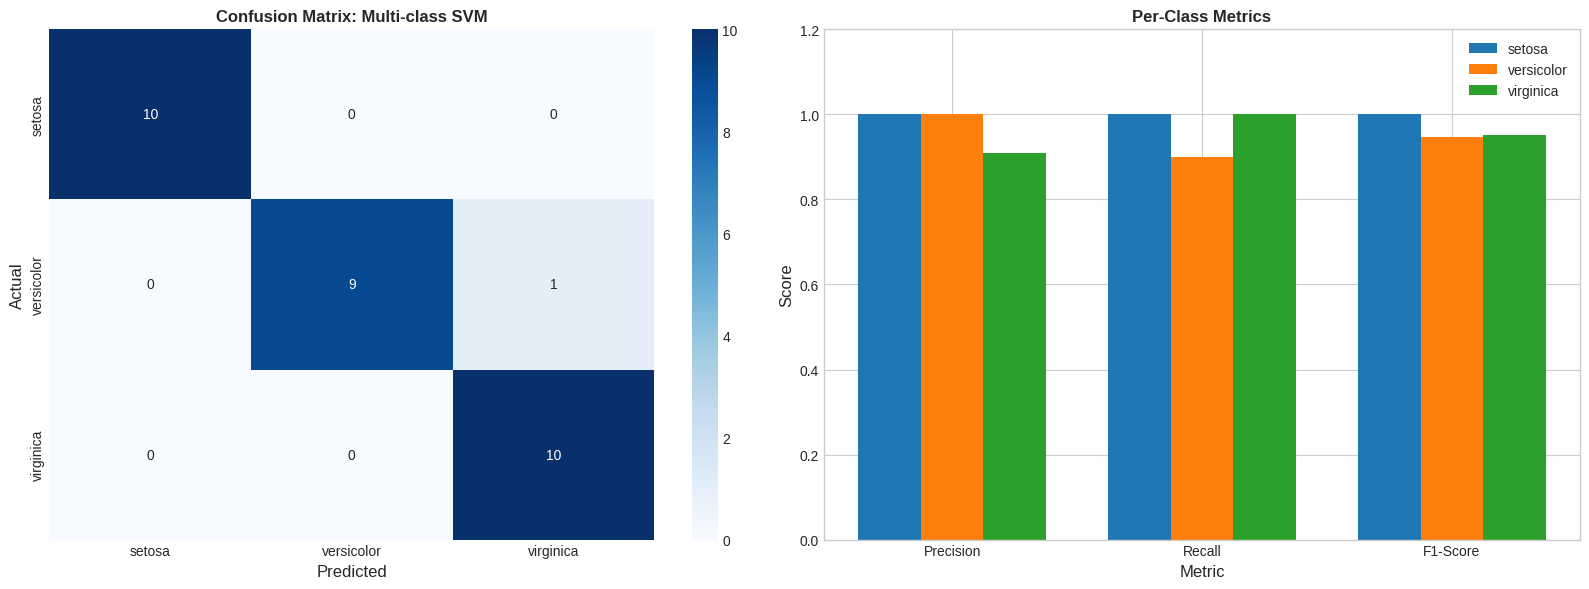

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, yticklabels=iris.target_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix: Multi-class SVM', fontsize=12, fontweight='bold')

from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)

ax = axes[1]
metrics = ['Precision', 'Recall', 'F1-Score']
x_pos = np.arange(len(iris.target_names))
width = 0.25
for idx, (name, vals) in enumerate(zip(iris.target_names, zip(precision, recall, f1))):
    offset = (idx - 1) * width
    ax.bar(x_pos + offset, vals, width, label=name)
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Metrics', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.2)

plt.tight_layout()
plt.show()


---
## Chapter 14: Grid Search Hyperparameter Tuning


In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1.0],
    'kernel': ['rbf']
}

print("Running Grid Search with Cross-Validation...")
print(f"Testing {len(param_grid['C']) * len(param_grid['gamma'])} combinations with 5-fold CV")

grid_search = GridSearchCV(
    SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1, return_train_score=True
)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")
print(f"Test accuracy: {grid_search.best_estimator_.score(X_test, y_test):.4f}")


Running Grid Search with Cross-Validation...
Testing 25 combinations with 5-fold CV

Best parameters: {'C': 1.0, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV accuracy: 0.9833
Test accuracy: 0.9667


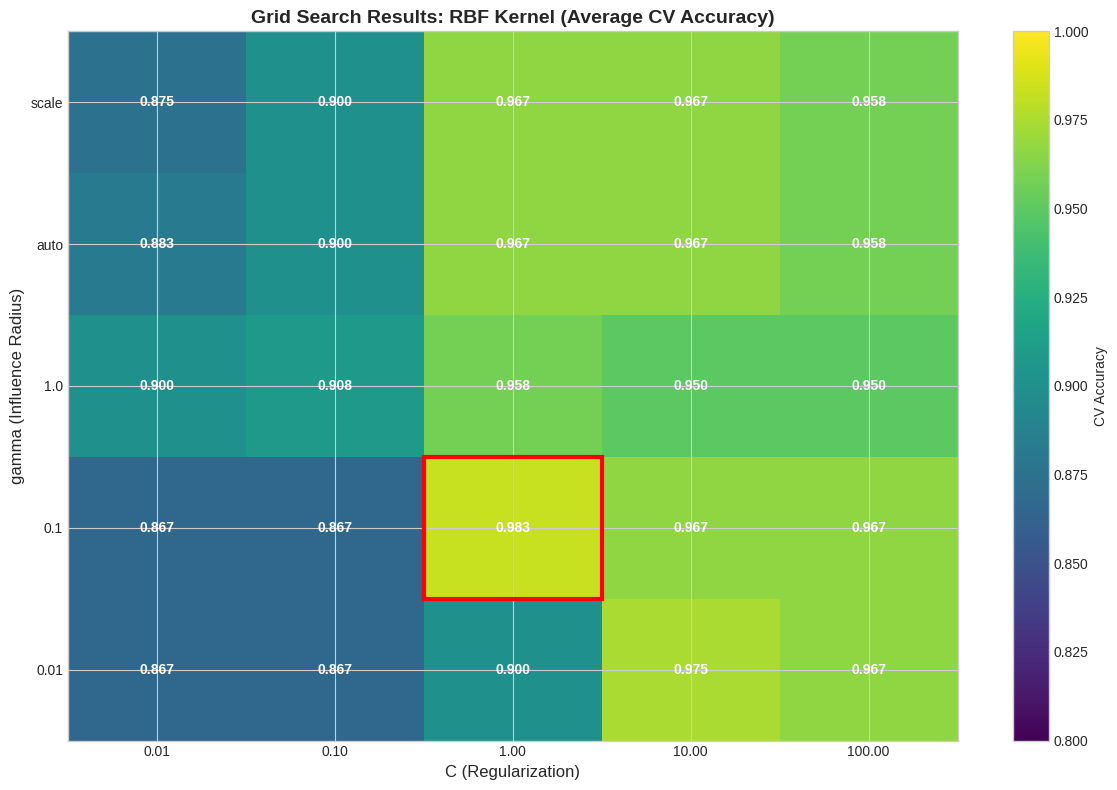

In [39]:
cv_results = grid_search.cv_results_
mask = cv_results['param_kernel'] == 'rbf'
c_values = cv_results['param_C'][mask].data
gamma_values = cv_results['param_gamma'][mask].data
scores = cv_results['mean_test_score'][mask]

c_unique = np.sort(np.unique(c_values))
gamma_unique = np.sort(np.unique([str(g) for g in gamma_values])) 
score_grid = np.zeros((len(gamma_unique), len(c_unique)))

for i, (c_val, gamma_val, score) in enumerate(zip(c_values, gamma_values, scores)):
    c_idx = np.searchsorted(c_unique, c_val)
    gamma_idx = np.searchsorted(gamma_unique, gamma_val)
    score_grid[gamma_idx, c_idx] = score

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(score_grid, cmap='viridis', aspect='auto', origin='lower', vmin=0.8, vmax=1.0)
ax.set_xticks(np.arange(len(c_unique)))
ax.set_yticks(np.arange(len(gamma_unique)))
ax.set_xticklabels([f'{c:.2f}' for c in c_unique])
ax.set_yticklabels([str(g) for g in gamma_unique])
ax.set_xlabel('C (Regularization)', fontsize=12)
ax.set_ylabel('gamma (Influence Radius)', fontsize=12)
ax.set_title('Grid Search Results: RBF Kernel (Average CV Accuracy)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='CV Accuracy')

for i in range(len(gamma_unique)):
    for j in range(len(c_unique)):
        ax.text(j, i, f'{score_grid[i, j]:.3f}', ha='center', va='center', color='white', fontsize=10, fontweight='bold')

best_idx = np.unravel_index(np.argmax(score_grid), score_grid.shape)
ax.add_patch(plt.Rectangle((best_idx[1]-0.5, best_idx[0]-0.5), 1, 1, fill=False, edgecolor='red', linewidth=3))

plt.tight_layout()
plt.show()


The red box marks the optimal C and gamma combination.


---
## Chapter 15: Summary and Key Takeaways

### What We've Learned

1. **SVM finds maximum margin hyperplane** - boundary with maximum distance to nearest points
2. **Support vectors are critical** - only points closest to boundary matter
3. **Kernel trick enables non-linear boundaries** - via implicit high-dimensional mapping
4. **C and gamma control bias-variance tradeoff** - small = simpler, large = complex
5. **Always scale features** - SVM uses distance calculations

### Kernel Selection Guide

| Situation | Kernel | Why |
|:----------|:-------|:----|
| High-dimensional (text, genes) | Linear | Often works best linearly |
| Unknown pattern | RBF (default) | Most flexible |
| Polynomial patterns | Polynomial | Captures polynomial boundaries |
| Neural network-like | Sigmoid | Similar to tanh |

### When to Use SVM

| Good For | Not Ideal For |
|:---------|:------------|
| Binary classification | Very large datasets |
| High-dimensional spaces | Very noisy data |
| Clear margin separation | Probabilistic outputs needed |
| Memory-efficient (sparse) | Uninformative features |


In [40]:
print("=" * 70)
print("SUPPORT VECTOR MACHINE - QUICK REFERENCE")
print("=" * 70)
print("\nKEY FORMULAS:")
print("-" * 40)
print("Hyperplane:      w.x + b = 0")
print("Margin Width:    2 / ||w||")
print("RBF Kernel:      exp(-gamma||x-x'||^2)")
print("\nHYPERPARAMETERS:")
print("-" * 40)
print("C:       Regularization (low=underfit, high=overfit)")
print("gamma:   RBF influence radius (low=smooth, high=complex)")
print("\nKERNEL SELECTION:")
print("-" * 40)
print("Linear:  High-dimensional, linearly separable")
print("RBF:     Default choice, most flexible")
print("Poly:    Polynomial patterns")
print("Sigmoid: Neural network-like")
print("\nPRO TIPS:")
print("-" * 40)
print("1. Always scale features before training SVM")
print("2. Start with RBF kernel and reasonable C")
print("3. Use GridSearchCV for hyperparameter tuning")
print("4. SVM is binary - use One-vs-Rest for multi-class")
print("=" * 70)


SUPPORT VECTOR MACHINE - QUICK REFERENCE

KEY FORMULAS:
----------------------------------------
Hyperplane:      w.x + b = 0
Margin Width:    2 / ||w||
RBF Kernel:      exp(-gamma||x-x'||^2)

HYPERPARAMETERS:
----------------------------------------
C:       Regularization (low=underfit, high=overfit)
gamma:   RBF influence radius (low=smooth, high=complex)

KERNEL SELECTION:
----------------------------------------
Linear:  High-dimensional, linearly separable
RBF:     Default choice, most flexible
Poly:    Polynomial patterns
Sigmoid: Neural network-like

PRO TIPS:
----------------------------------------
1. Always scale features before training SVM
2. Start with RBF kernel and reasonable C
3. Use GridSearchCV for hyperparameter tuning
4. SVM is binary - use One-vs-Rest for multi-class


---
## Congratulations!

You now have a solid understanding of Support Vector Machines!

### Next Steps
1. **Practice**: Try SVM on other datasets
2. **Experiment**: Modify C and gamma
3. **Explore**: Compare with other classifiers
4. **Dive Deeper**: Study convex optimization and Lagrangian duality

### Resources
- **Book**: "Pattern Classification" by Duda, Hart, and Stork
- **Online**: Andrew Ng's Machine Learning course (Coursera)
- **Practice**: Kaggle competitions

**Happy Learning!**
